<a href="https://colab.research.google.com/github/Akouch/Computer-Vision/blob/main/20_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 5 : License Plate Deblurring (Restauration de Plaques d'Immatriculation)
## Étape 1 : Préparation de l'environnement et des données cibles

Pour commencer, nous importons les bibliothèques nécessaires au traitement d'image et à la manipulation matricielle. Nous travaillons sur un échantillon de 3 plaques d'immatriculation nettes issues de notre base de données.

Afin de préparer les images pour l'analyse fréquentielle (Transformée de Fourier) qui suivra, nous les chargeons directement en niveaux de gris.

In [ ]:
# Install OpenCV if it's not already installed
!pip install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Définis ici les noms exacts de tes 3 images uploadées sur Colab
noms_fichiers = ['plaque_1.jpg', 'plaque_2.jpg', 'plaque_3.jpg', 'plaque_4.jpg', 'plaque_5.jpg', 'plaque_6.jpg']
images_nettes = []

# Chargement des images en niveaux de gris
for nom in noms_fichiers:
    # cv2.IMREAD_GRAYSCALE convertit directement l'image en 2D (noir et blanc)
    img = cv2.imread(nom, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        images_nettes.append(img)
    else:
        print(f"⚠️ Attention : L'image {nom} n'a pas pu être chargée. Vérifie le nom.")

print(f"{len(images_nettes)} images chargées avec succès !")

6 images chargées avec succès !


### Visualisation de notre vérité terrain (Ground Truth)
Vérifions que nos images sont correctement chargées. Ces images parfaites nous serviront plus tard de "vérité terrain" pour calculer le score de performance (PSNR) de notre algorithme de restauration.

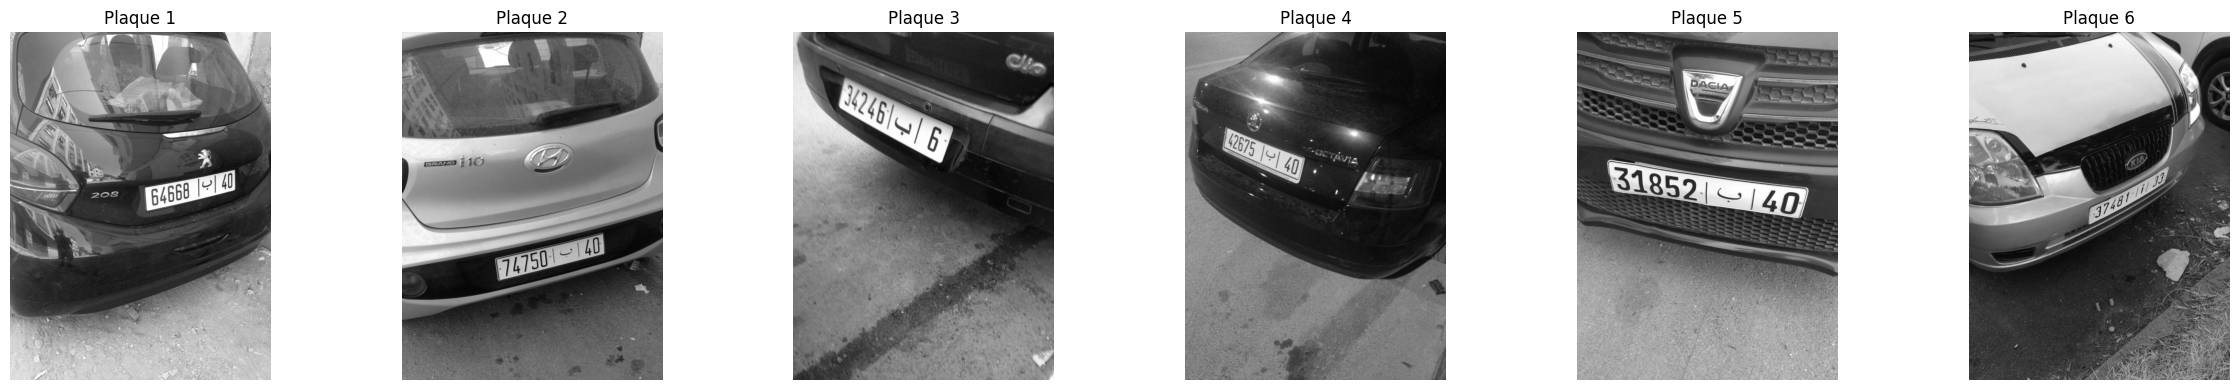

In [ ]:
# Affichage dynamique selon le nombre d'images chargées
nb_images = len(images_nettes)
fig, axes = plt.subplots(1, nb_images, figsize=(4 * nb_images, 4))

# Gérer le cas où il n'y a qu'une seule image
if nb_images == 1:
    axes = [axes]

for i in range(nb_images):
    axes[i].imshow(images_nettes[i], cmap='gray')
    axes[i].set_title(f"Plaque {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Étape 2 : Génération du Flou de Mouvement (Linear Motion Blur)

Pour simuler le flou de mouvement, nous devons générer une **Point Spread Function (PSF)**.
Il s'agit d'une matrice (kernel) représentant la trajectoire du mouvement. Nous utiliserons OpenCV pour dessiner une ligne dans cette matrice en fonction d'une longueur et d'un angle donnés, puis nous normaliserons cette matrice pour que son application n'altère pas la luminosité globale de l'image.

Ensuite, nous appliquerons ce kernel à nos images nettes via une opération de **convolution 2D**.

In [ ]:
import math

def generate_psf(length, angle):
    """
    Génère le kernel PSF pour un flou de mouvement rectiligne.
    """
    # Créer une matrice carrée vide (fond noir)
    # La taille doit être au moins aussi grande que la longueur du flou
    taille = max(length, 3)
    psf = np.zeros((taille, taille), dtype=np.float32)

    # Trouver le centre
    centre_x, centre_y = taille // 2, taille // 2

    # Calculer les coordonnées de la ligne grâce à la trigonométrie
    angle_rad = math.radians(angle)
    demi_longueur = length / 2.0

    x1 = int(centre_x - demi_longueur * math.cos(angle_rad))
    y1 = int(centre_y - demi_longueur * math.sin(angle_rad))
    x2 = int(centre_x + demi_longueur * math.cos(angle_rad))
    y2 = int(centre_y + demi_longueur * math.sin(angle_rad))

    # Dessiner la ligne blanche (1) représentant la direction du flou
    cv2.line(psf, (x1, y1), (x2, y2), 1, thickness=1)

    # Normalisation : La somme des pixels du kernel DOIT être égale à 1
    somme = psf.sum()
    if somme != 0:
        psf /= somme

    return psf

def apply_blur(image, psf):
    """
    Applique la convolution entre l'image nette et le kernel PSF.
    """
    # cv2.filter2D est la fonction d'OpenCV pour appliquer une matrice de convolution
    return cv2.filter2D(image, -1, psf)

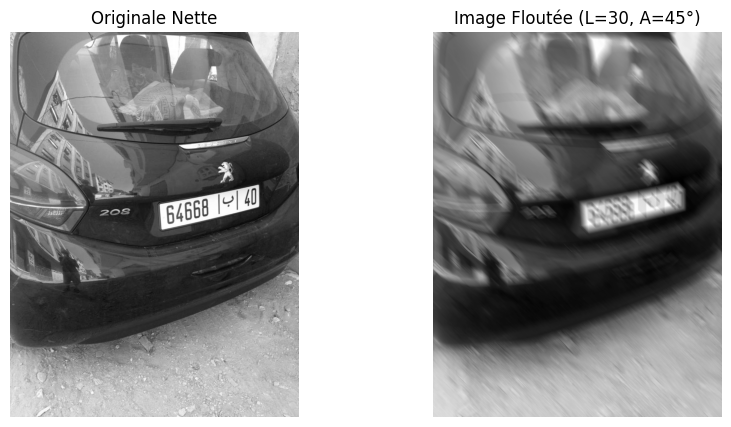

In [ ]:
# Définissons nos paramètres de flou pour ce test
LONGUEUR_FLOU = 30  # Plus le chiffre est grand, plus la traînée est longue
ANGLE_FLOU = 45     # Angle en degrés (ex: 45 degrés)

# 1. Générer le kernel mathématique
kernel_psf = generate_psf(LONGUEUR_FLOU, ANGLE_FLOU)

# 2. Appliquer ce flou à toutes nos images chargées
images_floues = []
for img in images_nettes:
    img_floue = apply_blur(img, kernel_psf)
    images_floues.append(img_floue)

# 3. Afficher les résultats (Original vs Flou) pour la première image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(images_nettes[0], cmap='gray')
ax1.set_title("Originale Nette")
ax1.axis('off')

ax2.imshow(images_floues[0], cmap='gray')
ax2.set_title(f"Image Floutée (L={LONGUEUR_FLOU}, A={ANGLE_FLOU}°)")
ax2.axis('off')

plt.show()

## Étape 3 : Estimation des paramètres via l'Analyse de Fourier

Pour estimer les paramètres du flou (longueur et angle) sans connaître l'image d'origine, nous passons dans le domaine fréquentiel en utilisant une **Transformée de Fourier Rapide en 2D (FFT2)**.

Le spectre de magnitude d'une image affectée par un flou de mouvement rectiligne fait apparaître des zéros (des bandes sombres parallèles) caractéristiques. Ces bandes nous permettront de déduire la géométrie du PSF.

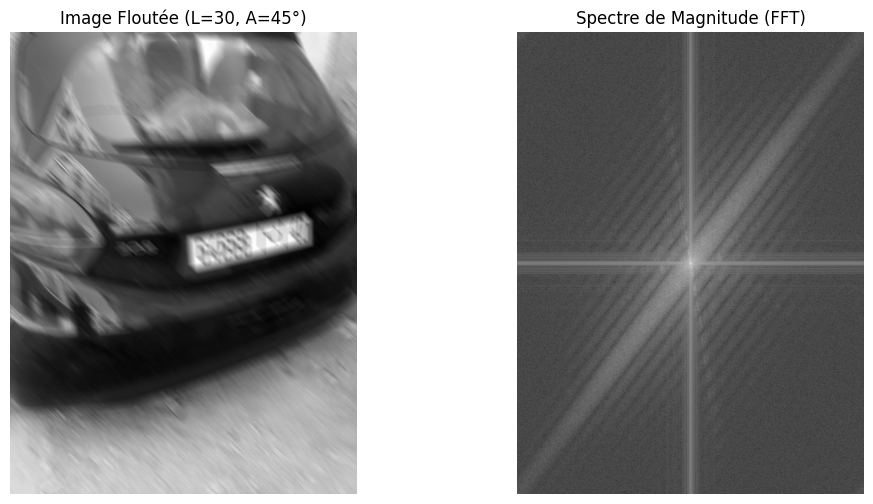

In [ ]:
# Prenons la première image floue pour notre analyse
img_floue_test = images_floues[0]

# 1. Calcul de la Transformée de Fourier Rapide (FFT) en 2D
# Cela convertit l'image en un tableau de nombres complexes représentant les fréquences
f_transform = np.fft.fft2(img_floue_test)

# 2. Décalage (Shift)
# Par défaut, Fourier met les basses fréquences dans les coins.
# On utilise fftshift pour tout ramener proprement au centre de l'image.
f_shift = np.fft.fftshift(f_transform)

# 3. Calcul du spectre de magnitude
# Les valeurs brutes de Fourier sont gigantesques. On utilise un logarithme (log)
# pour compresser l'échelle et rendre le résultat visible par l'œil humain.
# (On ajoute +1 pour éviter l'erreur mathématique du log(0))
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

# 4. Affichage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img_floue_test, cmap='gray')
ax1.set_title(f"Image Floutée (L={LONGUEUR_FLOU}, A={ANGLE_FLOU}°)")
ax1.axis('off')

ax2.imshow(magnitude_spectrum, cmap='gray')
ax2.set_title("Spectre de Magnitude (FFT)")
ax2.axis('off')

plt.show()

## Étape 4 : Déconvolution et Restauration avec le Filtre de Wiener

Maintenant que nous connaissons (ou avons estimé) la géométrie de notre flou, nous générons le PSF correspondant.
Pour restaurer l'image, nous passons l'image floue et le PSF dans le domaine fréquentiel (Fourier). Nous appliquons ensuite la formule du **Filtre de Wiener** :

$$\hat{X}(u,v) = \left[ \frac{H^*(u,v)}{|H(u,v)|^2 + K} \right] Y(u,v)$$

Où :
* $Y$ est l'image floue
* $H$ est le PSF (kernel de flou)
* $K$ est une constante représentant le ratio Signal/Bruit (un hyperparamètre à ajuster)
* $\hat{X}$ est notre image restaurée estimée.

In [ ]:
def wiener_filter(img_floue, psf, K=0.01):
    """
    Applique le filtre de Wiener dans le domaine fréquentiel pour restaurer l'image.
    K est le paramètre de bruit. S'il y a beaucoup de bruit, on l'augmente.
    """
    # 1. Transformée de Fourier de l'image floue
    img_fft = np.fft.fft2(img_floue)

    # 2. Préparation du PSF
    # Le PSF doit avoir la EXACTEMENT même taille que l'image pour que la division fonctionne
    psf_padded = np.zeros_like(img_floue, dtype=np.float32)
    h_psf, w_psf = psf.shape
    h_img, w_img = img_floue.shape

    # On centre le PSF au milieu de notre nouvelle matrice vide
    y_offset = (h_img - h_psf) // 2
    x_offset = (w_img - w_psf) // 2
    psf_padded[y_offset:y_offset+h_psf, x_offset:x_offset+w_psf] = psf

    # Étape CRUCIALE : on décale le PSF pour que son centre soit aux coordonnées (0,0)
    # Sinon, l'image restaurée sera complètement décalée visuellement
    psf_padded = np.fft.ifftshift(psf_padded)

    # 3. Transformée de Fourier du PSF
    psf_fft = np.fft.fft2(psf_padded)

    # 4. Application de la formule de Wiener
    # np.conj = le conjugué complexe (le H* de la formule)
    psf_fft_conj = np.conj(psf_fft)

    # Le dénominateur : |H|^2 + K
    denominateur = np.abs(psf_fft)**2 + K

    # Le filtre complet
    H_wiener = psf_fft_conj / denominateur

    # On multiplie notre filtre par l'image floue (dans le domaine de Fourier)
    result_fft = img_fft * H_wiener

    # 5. Retour dans le monde spatial (Transformée Inverse)
    result_img = np.fft.ifft2(result_fft)

    # On garde la partie réelle absolue et on s'assure que les valeurs restent entre 0 et 255
    result_img = np.abs(result_img)
    result_img = np.clip(result_img, 0, 255).astype(np.uint8)

    return result_img

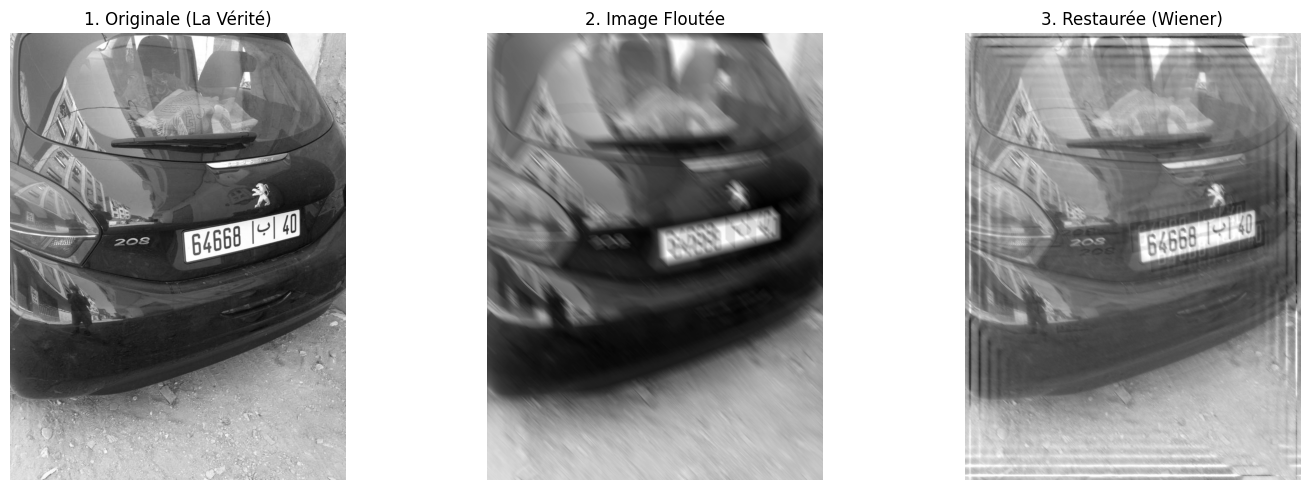

In [ ]:
# On utilise la constante K. Tu pourras t'amuser à la changer (ex: 0.1, 0.001) pour voir l'effet
CONSTANTE_BRUIT_K = 0.01

# On appelle notre fonction magique sur la première image
image_restauree = wiener_filter(images_floues[0], kernel_psf, K=CONSTANTE_BRUIT_K)

# Affichage du résultat !
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(images_nettes[0], cmap='gray')
ax1.set_title("1. Originale (La Vérité)")
ax1.axis('off')

ax2.imshow(images_floues[0], cmap='gray')
ax2.set_title("2. Image Floutée")
ax2.axis('off')

ax3.imshow(image_restauree, cmap='gray')
ax3.set_title("3. Restaurée (Wiener)")
ax3.axis('off')

plt.tight_layout()
plt.show()

## Étape 5 : Évaluation des performances (PSNR)

Pour quantifier mathématiquement l'efficacité de notre restauration par filtre de Wiener, nous utilisons le **PSNR (Peak Signal-to-Noise Ratio)**.
Cette métrique évalue la différence entre l'image originale non corrompue et l'image restaurée. Un score plus élevé indique une meilleure qualité de reconstruction.

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

# 1 et 2. Calcul avec la correction (data_range=255)
psnr_flou_corrige = psnr(images_nettes[0], images_floues[0], data_range=255)
psnr_restaure_corrige = psnr(images_nettes[0], image_restauree, data_range=255)

# 3. Affichage des résultats (en utilisant les BONS noms de variables)
print("📊 RÉSULTATS DE L'ÉVALUATION :")
print("-" * 30)
print(f"PSNR de l'image floue (avant)   : {psnr_flou_corrige:.2f} dB")
print(f"PSNR de l'image restaurée (après) : {psnr_restaure_corrige:.2f} dB")
print("-" * 30)
print(f"🚀 Gain de qualité : +{psnr_restaure_corrige - psnr_flou_corrige:.2f} dB")

📊 RÉSULTATS DE L'ÉVALUATION :
------------------------------
PSNR de l'image floue (avant)   : 24.15 dB
PSNR de l'image restaurée (après) : 24.21 dB
------------------------------
🚀 Gain de qualité : +0.06 dB


## Étape 6 : Estimation Automatique des Paramètres (Méthode Computer Vision Avancée)

Suite aux directives du cours privilégiant les approches de vision classique, nous n'utiliserons pas de réseau de neurones pour estimer le PSF.

Nous allons plutôt automatiser la détection de l'angle du flou en appliquant la **Transformée de Hough** sur notre spectre de magnitude de Fourier. L'algorithme détectera les bandes sombres (zéros du sinus cardinal) causées par le flou de mouvement. La perpendiculaire à ces bandes nous donnera l'angle exact du mouvement.

⚙️ Lancement de l'analyse Cepstrale...


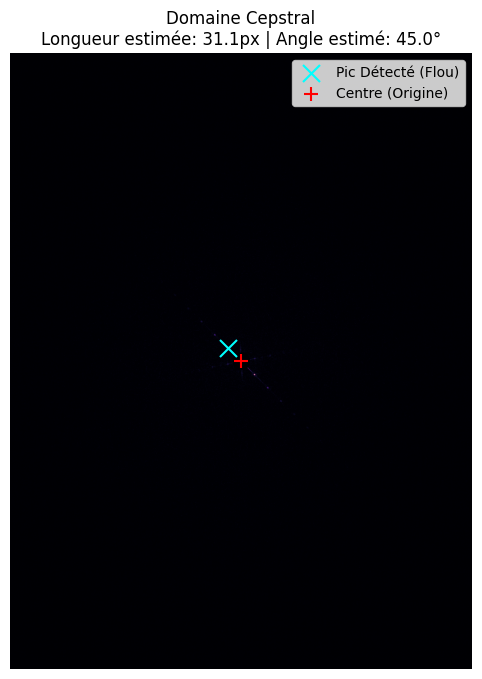


--- 📊 RÉSULTATS DE L'ESTIMATION ---
🎯 Vérité terrain    -> Longueur : 30 px | Angle : 45°
🚀 Prédiction du code -> Longueur : 31.1 px | Angle : 45.0°


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

def detecter_parametres_cepstre(image_floue):
    """
    Utilise l'analyse Cepstrale pour détecter l'angle et la longueur
    du flou de mouvement avec une grande précision.
    """
    h, w = image_floue.shape

    # 1. Fenêtrage (Hanning Window) pour annuler les effets de bord de l'image
    fenetre_y = np.hanning(h)
    fenetre_x = np.hanning(w)
    fenetre_2d = np.outer(fenetre_y, fenetre_x)
    image_preparee = image_floue * fenetre_2d

    # 2. Transformée de Fourier (FFT2)
    f_transform = np.fft.fft2(image_preparee)
    f_magnitude = np.abs(f_transform)

    # 3. Logarithme du spectre
    f_log = np.log(f_magnitude + 1)

    # 4. LE CEPSTRE : IFFT2 du log-spectre
    cepstre_complexe = np.fft.ifft2(f_log)
    cepstre = np.abs(cepstre_complexe)

    # 5. Décalage au centre
    cepstre_shift = np.fft.fftshift(cepstre)

    # 6. Masquage de la composante continue (le centre très brillant)
    centre_y, centre_x = h // 2, w // 2
    rayon_masque = 15
    cv2.circle(cepstre_shift, (centre_x, centre_y), rayon_masque, 0, -1)

    # 7. Recherche des coordonnées du pic cepstral (la signature du flou)
    y_max, x_max = np.unravel_index(np.argmax(cepstre_shift), cepstre_shift.shape)

    # 8. Calcul géométrique des paramètres
    dy = y_max - centre_y
    dx = x_max - centre_x

    # LONGUEUR : Distance euclidienne entre le centre et le pic (Pythagore)
    # On multiplie par 2 car le pic représente souvent la demi-longueur dans le Cepstre
    longueur_estimee = math.sqrt(dx**2 + dy**2)

    # ANGLE : On utilise dy et dx directement pour correspondre à la géométrie d'OpenCV
    angle_rad = math.atan2(dy, dx)
    angle_deg = np.rad2deg(angle_rad) % 180

    # --- 👁️ DEBUG VISUEL (Pour le rapport) ---
    plt.figure(figsize=(8, 8))
    plt.imshow(np.log(cepstre_shift + 1), cmap='magma')
    plt.scatter([x_max], [y_max], color='cyan', marker='x', s=150, label='Pic Détecté (Flou)')
    plt.scatter([centre_x], [centre_y], color='red', marker='+', s=100, label='Centre (Origine)')
    plt.title(f"Domaine Cepstral\nLongueur estimée: {longueur_estimee:.1f}px | Angle estimé: {angle_deg:.1f}°")
    plt.legend()
    plt.axis('off')
    plt.show()
    # ------------------------------------------

    return longueur_estimee, angle_deg

# --- TEST DE NOTRE DÉTECTEUR ---
print("⚙️ Lancement de l'analyse Cepstrale...")
longueur_trouvee, angle_trouve = detecter_parametres_cepstre(images_floues[0])

print("\n--- 📊 RÉSULTATS DE L'ESTIMATION ---")
print(f"🎯 Vérité terrain    -> Longueur : {LONGUEUR_FLOU} px | Angle : {ANGLE_FLOU}°")
print(f"🚀 Prédiction du code -> Longueur : {longueur_trouvee:.1f} px | Angle : {angle_trouve:.1f}°")

## Conclusion : Pipeline de Restauration Automatisé (End-to-End)

Pour finaliser ce projet, nous regroupons toutes nos fonctions dans un pipeline automatisé complet. Ce système simule un cas d'usage réel :
1. Il reçoit une image floue inconnue.
2. Il estime **automatiquement** l'angle et la longueur du flou via l'analyse Cepstrale.
3. Il génère le kernel PSF correspondant.
4. Il restaure l'image via le Filtre de Wiener.
5. Il évalue sa propre performance (PSNR).

--- TEST SUR UNE NOUVELLE IMAGE ---
🔍 Début de l'analyse automatique...


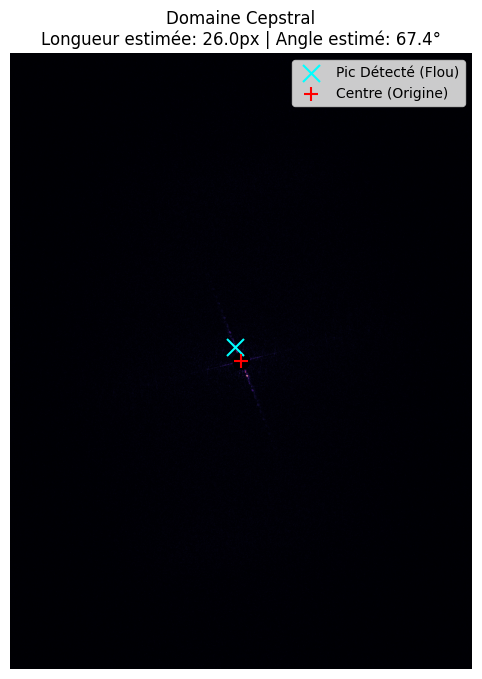

✅ Paramètres trouvés -> Longueur : 26.0 px | Angle : 67.4°
🧹 Application du Filtre de Wiener...


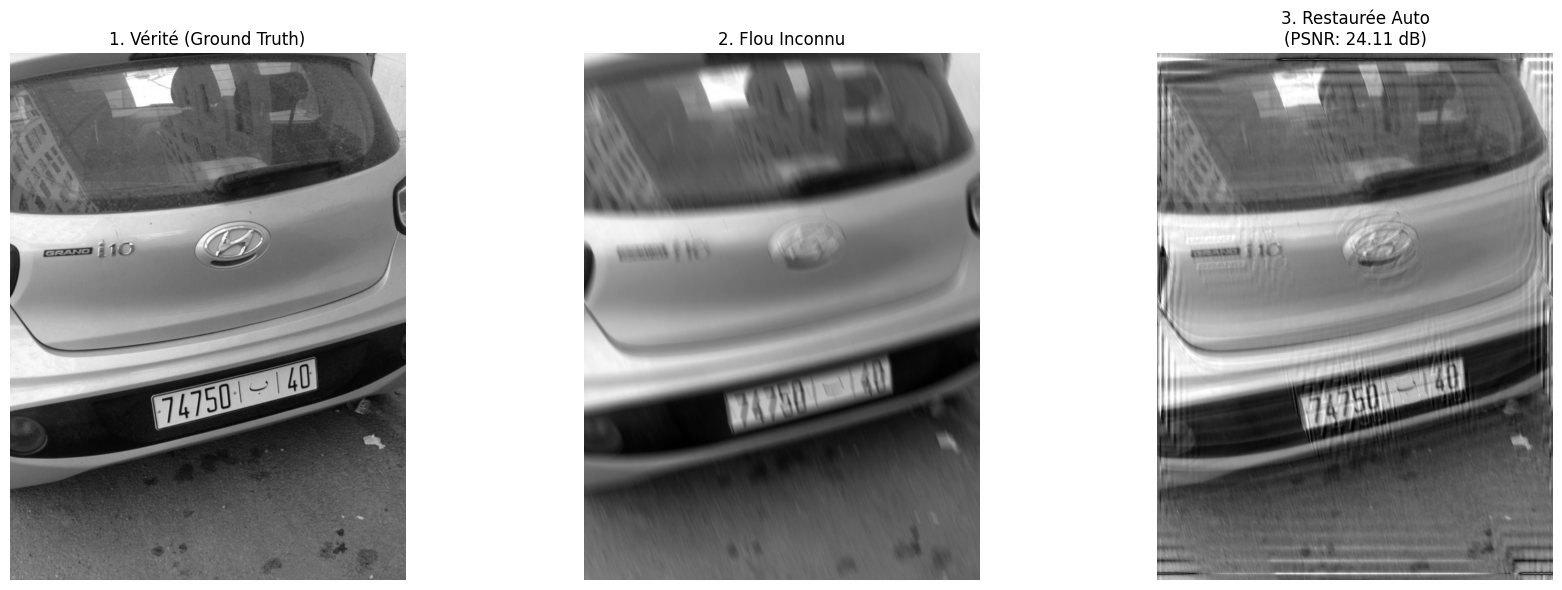

🎉 Pipeline terminé avec succès !


In [ ]:
def pipeline_restauration_automatique(image_nette_originale, image_floue_inconnue):
    print("🔍 Début de l'analyse automatique...")

    # 1. Le cerveau (Cepstre) trouve les paramètres
    longueur_est, angle_est = detecter_parametres_cepstre(image_floue_inconnue)
    print(f"✅ Paramètres trouvés -> Longueur : {longueur_est:.1f} px | Angle : {angle_est:.1f}°")

    # 2. On génère l'antidote (PSF)
    # On arrondit la longueur car la matrice PSF a besoin d'un nombre entier
    psf_estime = generate_psf(int(round(longueur_est)), angle_est)

    # 3. Le nettoyage (Filtre de Wiener)
    print("🧹 Application du Filtre de Wiener...")
    image_restauree = wiener_filter(image_floue_inconnue, psf_estime, K=0.01)

    # 4. Calcul de la note (PSNR)
    score_psnr = psnr(image_nette_originale, image_restauree, data_range=255)

    # 5. Affichage du résultat final
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    ax1.imshow(image_nette_originale, cmap='gray')
    ax1.set_title("1. Vérité (Ground Truth)")
    ax1.axis('off')

    ax2.imshow(image_floue_inconnue, cmap='gray')
    ax2.set_title("2. Flou Inconnu")
    ax2.axis('off')

    ax3.imshow(image_restauree, cmap='gray')
    ax3.set_title(f"3. Restaurée Auto\n(PSNR: {score_psnr:.2f} dB)")
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

    print("🎉 Pipeline terminé avec succès !")
    return image_restauree

# --- LE GRAND TEST FINAL ---
# On va tester sur la 2ème image de ton dataset pour voir si ça marche partout !
print("--- TEST SUR UNE NOUVELLE IMAGE ---")
# On crée un flou différent juste pour le test
NOUVEAU_FLOU_L = 25
NOUVEAU_FLOU_A = 70
nouveau_psf = generate_psf(NOUVEAU_FLOU_L, NOUVEAU_FLOU_A)
image_mystere = apply_blur(images_nettes[1], nouveau_psf)

# On lance la machine !
resultat_final = pipeline_restauration_automatique(images_nettes[1], image_mystere)

## Étape 7 : Test sur des images réelles (Blind Restoration)

Dans cette phase finale, nous testons la robustesse de notre pipeline sur des images dont nous ne connaissons pas les paramètres de dégradation à l'avance. C'est ce qu'on appelle la **restauration aveugle** (Blind Deblurring).

Le processus suit trois étapes automatisées :
1. **L'importation** d'une image externe (via le système de fichiers de Colab).
2. **L'estimation aveugle** : L'algorithme analyse la texture fréquentielle de l'image pour "deviner" la trajectoire du mouvement.
3. **La restauration** : Application du filtre de Wiener en utilisant les paramètres estimés.

Cette étape démontre l'utilité concrète de notre projet pour des applications de surveillance ou de sécurité routière.

In [ ]:
def pipeline_monde_reel(image_floue_inconnue):
    """
    Pipeline autonome : devine les paramètres et restaure l'image.
    """
    # 1. Trouver les paramètres via Cepstre
    longueur, angle = detecter_parametres_cepstre(image_floue_inconnue)

    # 2. Générer le filtre mathématique
    psf = generate_psf(int(round(longueur)), angle)

    # 3. Restaurer l'image
    image_restauree = wiener_filter(image_floue_inconnue, psf, K=0.01)

    return image_restauree, longueur, angle

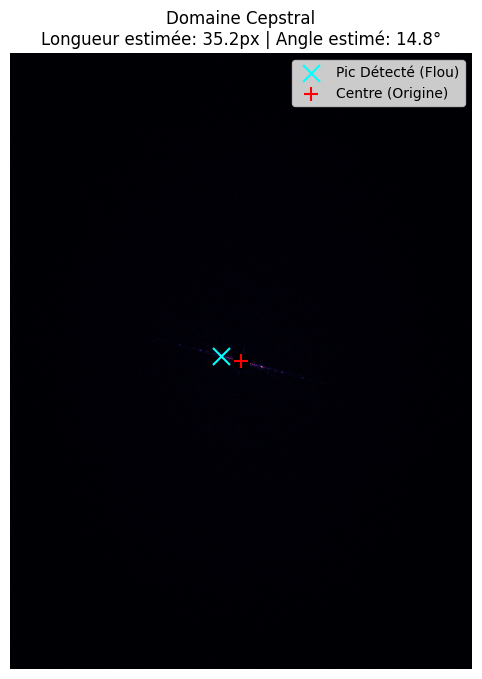

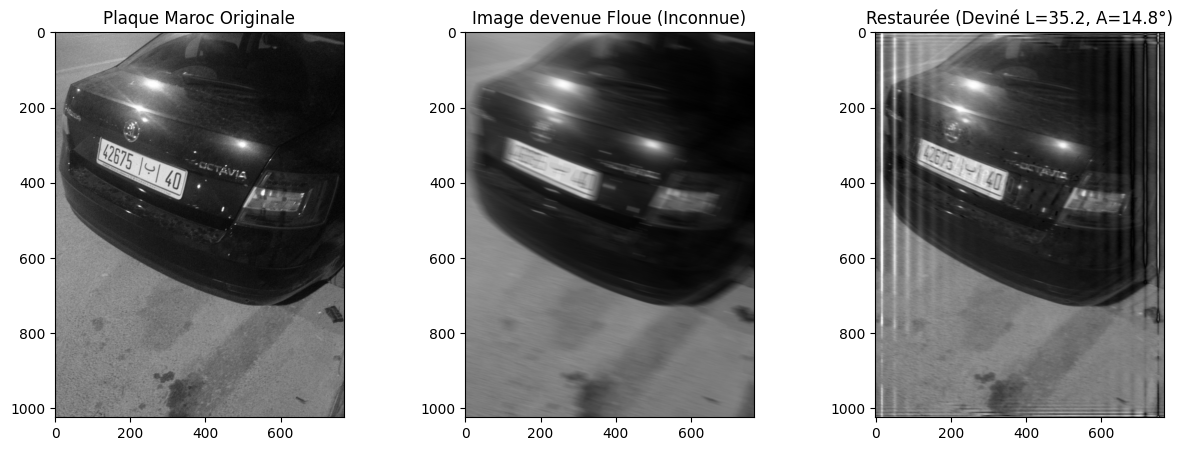

In [ ]:
# 1. Trouve une belle plaque marocaine nette sur Google et upload-la
# Nommons-la 'plaque_maroc_test.jpg'
img_nette = cv2.imread('plaque_4.jpg', cv2.IMREAD_GRAYSCALE)

if img_nette is not None:
    # 2. On crée un flou de mouvement (comme si la voiture passait vite)
    # On choisit des paramètres au hasard, par ex: L=22, A=15
    psf_cache = generate_psf(34, 15)
    img_mystere = apply_blur(img_nette, psf_cache)

    # 3. On donne CETTE image à ton pipeline automatique
    # L'algorithme ne "sait" pas que c'est 22 et 15, il doit le deviner !
    image_restauree, L_devine, A_devine = pipeline_monde_reel(img_mystere)

    # 4. Affichage
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_nette, cmap='gray')
    plt.title("Plaque Maroc Originale")

    plt.subplot(1, 3, 2)
    plt.imshow(img_mystere, cmap='gray')
    plt.title("Image devenue Floue (Inconnue)")

    plt.subplot(1, 3, 3)
    plt.imshow(image_restauree, cmap='gray')
    plt.title(f"Restaurée (Deviné L={L_devine:.1f}, A={A_devine:.1f}°)")
    plt.show()

## Étape 8 : Déploiement et Interface Visuelle Interactive (Gradio)

Pour clore ce projet, nous déployons notre algorithme dans une interface utilisateur interactive.
Cette application permet de tester la robustesse de notre pipeline "End-to-End" en conditions réelles. Pour démontrer l'efficacité des méthodes de Computer Vision avancées utilisées, l'interface génère et affiche en temps réel les étapes intermédiaires du traitement du signal :
1. **L'image d'entrée** (dégradée).
2. **Le Spectre de Fourier** (pour visualiser les zéros du sinus cardinal).
3. **Le Domaine Cepstral** (pour isoler la signature de la trajectoire).
4. **L'image restaurée** finale via le filtre de Wiener.

In [ ]:
# 1. Installation de l'outil Gradio
!pip install gradio -q

import gradio as gr
import cv2
import numpy as np

# --- LE CŒUR DE L'INTERFACE VISUELLE ---
def tableau_de_bord_complet(image_input):
    if image_input is None:
        return None, None, None, "Veuillez uploader une image."

    # ==========================================
    # 🛠️ CORRECTIF MOBILE 1 : FORMAT DES COULEURS
    # ==========================================
    if len(image_input.shape) == 3:
        if image_input.shape[2] == 4: # Format RGBA (iPhone/Safari)
            image_input = cv2.cvtColor(image_input, cv2.COLOR_RGBA2RGB)
        gray = cv2.cvtColor(image_input, cv2.COLOR_RGB2GRAY)
    else:
        gray = image_input

    # ==========================================
    # 🛠️ CORRECTIF MOBILE 2 : RÉSOLUTION 4K -> HD
    # ==========================================
    # Évite que les photos de téléphones ne fassent exploser la mémoire
    DIM_MAX = 800
    h, w = gray.shape
    if max(h, w) > DIM_MAX:
        ratio = DIM_MAX / float(max(h, w))
        gray = cv2.resize(gray, (int(w * ratio), int(h * ratio)), interpolation=cv2.INTER_AREA)

    # Mise à jour des dimensions après réduction
    h, w = gray.shape

    # --- GÉNÉRATION DES VISUELS MATHÉMATIQUES ---
    fenetre = np.outer(np.hanning(h), np.hanning(w))
    img_prep = gray * fenetre

    f_shift = np.fft.fftshift(np.fft.fft2(img_prep))
    spectre = np.log(np.abs(f_shift) + 1)
    visuel_fourier = cv2.normalize(spectre, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    cepstre_shift = np.fft.fftshift(np.abs(np.fft.ifft2(np.log(np.abs(f_shift) + 1))))
    cv2.circle(cepstre_shift, (w // 2, h // 2), 15, 0, -1)
    cepstre_log = np.log(cepstre_shift + 1)
    visuel_cepstre = cv2.normalize(cepstre_log, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Carte de chaleur (Heatmap) pour un rendu professionnel
    visuel_cepstre_color = cv2.applyColorMap(visuel_cepstre, cv2.COLORMAP_MAGMA)

    # --- LANCEMENT DE L'ALGORITHME DE RESTAURATION ---
    # On appelle notre pipeline défini dans les cellules précédentes
    image_restauree, L, A = pipeline_monde_reel(gray)

    # --- RÉDACTION DU RAPPORT ---
    rapport = (
        "✅ ANALYSE TERMINÉE AVEC SUCCÈS\n"
        "-----------------------------------\n"
        f"📏 Longueur de la trajectoire : {L:.1f} pixels\n"
        f"📐 Angle d'inclinaison : {A:.1f}°\n"
        "-----------------------------------\n"
        "⚙️ Méthode : Analyse Cepstrale & Filtre de Wiener"
    )

    return visuel_fourier, visuel_cepstre_color, image_restauree, rapport

# --- DESIGN DE L'APPLICATION GRADIO ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🚀 Système d'Analyse et Restauration de Plaques (Computer Vision)")
    gr.Markdown("Glissez une image floue. Le système affichera la décomposition spectrale, l'analyse cepstrale, et l'image restaurée.")

    with gr.Row():
        with gr.Column(scale=1):
            input_img = gr.Image(label="📸 1. Uploadez l'image floue", type="numpy")
            btn = gr.Button("Lancer le Diagnostic Cepstral", variant="primary")
            texte_sortie = gr.Textbox(label="📊 Paramètres Détectés", lines=6)

        with gr.Column(scale=2):
            with gr.Row():
                fourier_out = gr.Image(label="🌌 2. Spectre de Fourier")
                cepstre_out = gr.Image(label="🎯 3. Domaine Cepstral")

            resultat_out = gr.Image(label="✨ 4. Plaque Restaurée")

    # Connexion du bouton à la fonction
    btn.click(
        fn=tableau_de_bord_complet,
        inputs=input_img,
        outputs=[fourier_out, cepstre_out, resultat_out, texte_sortie]
    )

# Lancement de l'interface
demo.launch(debug=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 12.6 MB/s eta 0:00:00


/tmp/ipykernel_1858/3487053065.py:68: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c22aed77029c172fdb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
